# 📊 NOTEBOOK 06 — Comparaison Finale & Export pour Streamlit
## Objectifs
1. Charger les résultats JSON des notebooks 03, 04, 05
2. Générer tous les graphiques comparatifs
3. **Créer `all_results.pkl`** — le fichier unique lu par Streamlit
4. Vérifier que tout est en ordre pour lancer l'application

> **Prérequis :** avoir exécuté les notebooks 03, 04 et 05.

## 1. Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.manifold import TSNE
import os, pickle, json
import warnings
warnings.filterwarnings('ignore')

PROC_DIR    = "../data/processed/"
OUT_MODELS  = "../outputs/models/"
OUT_PLOTS   = "../outputs/plots/"
OUT_RESULTS = "../outputs/results/"

with open(PROC_DIR + "config.pkl", "rb") as f:
    cfg = pickle.load(f)
N_CLASSES = cfg["N_CLASSES"]

CLASS_NAMES = np.load(PROC_DIR + "class_names.npy", allow_pickle=True)
X_test      = np.load(PROC_DIR + "X_test.npy")
y_test      = np.load(PROC_DIR + "y_test.npy")
print("✅ Données de test chargées")


✅ Données de test chargées


## 2. Charger les résultats JSON

In [4]:
files_map = {
    "CNN (scratch)":       "results_cnn_scratch.json",
    "ResNet50 (TL)":       "results_resnet50.json",
    "EfficientNetB0 (TL)": "results_efficientnet.json",
}

all_results = {}
for name, fname in files_map.items():
    path = OUT_RESULTS + fname
    if os.path.exists(path):
        with open(path) as f:
            all_results[name] = json.load(f)
        acc = all_results[name]["accuracy"]*100
        f1  = all_results[name]["f1_score"]*100
        print(f"✅ {name:25} → Acc={acc:.2f}%  F1={f1:.2f}%")
    else:
        print(f"⚠️  {name} : fichier manquant — exécute d'abord le notebook correspondant")


✅ CNN (scratch)             → Acc=15.24%  F1=5.98%
✅ ResNet50 (TL)             → Acc=76.67%  F1=76.66%
✅ EfficientNetB0 (TL)       → Acc=79.05%  F1=78.77%


## 3. Tableau comparatif

In [5]:
rows = []
for name, res in all_results.items():
    rows.append({
        "Modèle":       name,
        "Accuracy (%)": f"{res['accuracy']*100:.2f}",
        "F1-Score (%)": f"{res['f1_score']*100:.2f}",
        "Paramètres":   {"CNN (scratch)":"~500K",
                          "ResNet50 (TL)":"25.6M",
                          "EfficientNetB0 (TL)":"5.3M"}.get(name, "—"),
    })
df_comp = pd.DataFrame(rows)
print()
print(df_comp.to_string(index=False))



             Modèle Accuracy (%) F1-Score (%) Paramètres
      CNN (scratch)        15.24         5.98      ~500K
      ResNet50 (TL)        76.67        76.66      25.6M
EfficientNetB0 (TL)        79.05        78.77       5.3M


## 4. Graphique de comparaison — Accuracy & F1

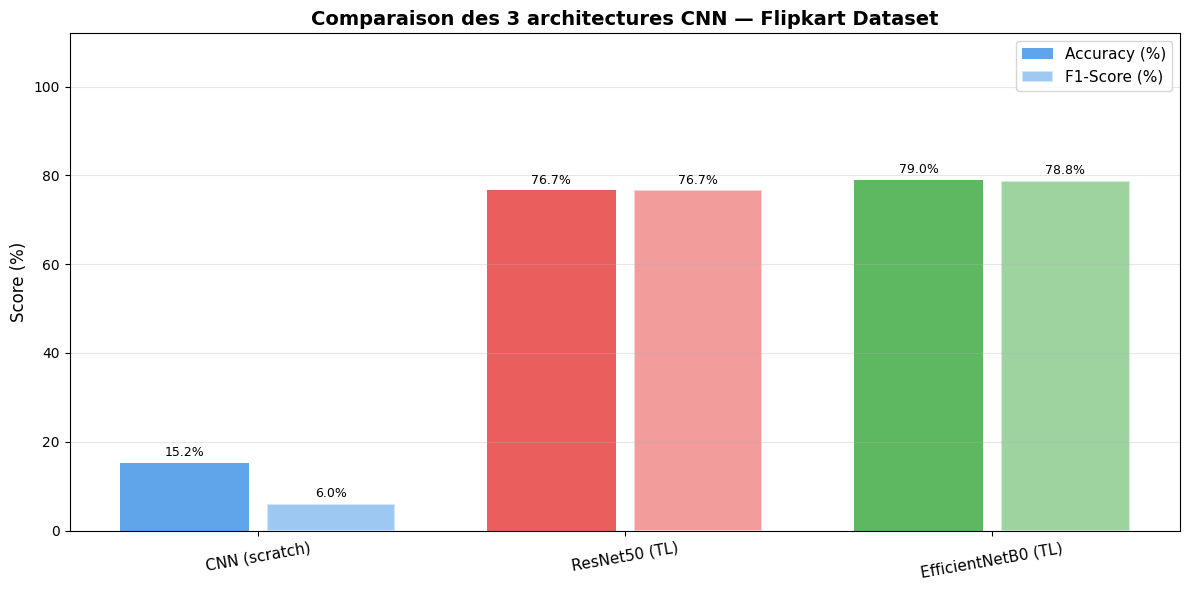

💾 outputs/plots/06_comparison_final.png


In [6]:
names  = list(all_results.keys())
accs   = [all_results[n]["accuracy"]*100 for n in names]
f1s    = [all_results[n]["f1_score"]*100  for n in names]
colors = ["#4C9BE8", "#E84C4C", "#4CAF50"]

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x-0.2, accs, 0.35, label="Accuracy (%)", color=colors, alpha=0.9)
b2 = ax.bar(x+0.2, f1s,  0.35, label="F1-Score (%)",
            color=colors, alpha=0.55, edgecolor="white", linewidth=1.5)

ax.set_xticks(x); ax.set_xticklabels(names, fontsize=11, rotation=10)
ax.set_ylim(0, 112); ax.set_ylabel("Score (%)", fontsize=12)
ax.set_title("Comparaison des 3 architectures CNN — Flipkart Dataset",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=11); ax.grid(axis="y", alpha=0.3)

for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(OUT_PLOTS + "06_comparison_final.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 outputs/plots/06_comparison_final.png")


## 5. Courbes d'entraînement côte à côte

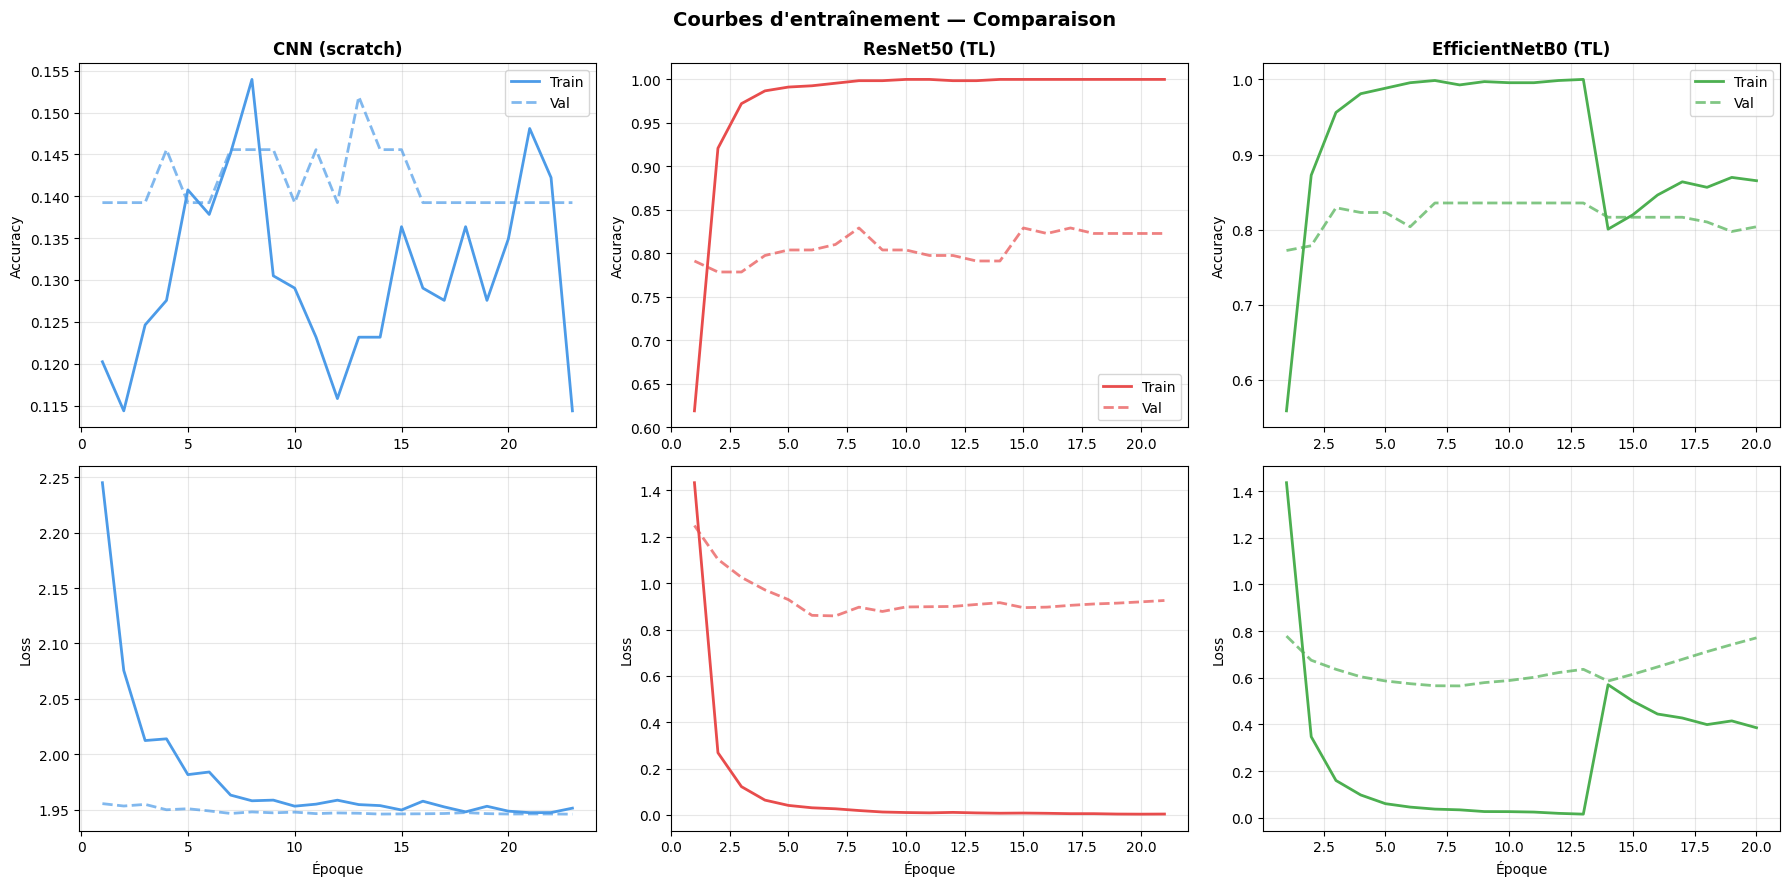

In [7]:
n_models = len(all_results)
fig, axes = plt.subplots(2, n_models, figsize=(6*n_models, 9))
fig.suptitle("Courbes d'entraînement — Comparaison", fontsize=14, fontweight="bold")
col_map = {"CNN (scratch)":"#4C9BE8","ResNet50 (TL)":"#E84C4C","EfficientNetB0 (TL)":"#4CAF50"}

for col, (name, res) in enumerate(all_results.items()):
    h  = res["history"]
    ep = range(1, len(h["accuracy"])+1)
    c_ = col_map[name]
    axes[0][col].plot(ep, h["accuracy"],     color=c_, lw=2,  label="Train")
    axes[0][col].plot(ep, h["val_accuracy"], color=c_, lw=2, ls="--", alpha=0.7, label="Val")
    axes[0][col].set_title(name, fontweight="bold"); axes[0][col].set_ylabel("Accuracy")
    axes[0][col].legend(); axes[0][col].grid(alpha=0.3)
    axes[1][col].plot(ep, h["loss"],     color=c_, lw=2)
    axes[1][col].plot(ep, h["val_loss"], color=c_, lw=2, ls="--", alpha=0.7)
    axes[1][col].set_ylabel("Loss"); axes[1][col].set_xlabel("Époque")
    axes[1][col].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_PLOTS + "06_training_curves_all.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Matrices de confusion côte à côte

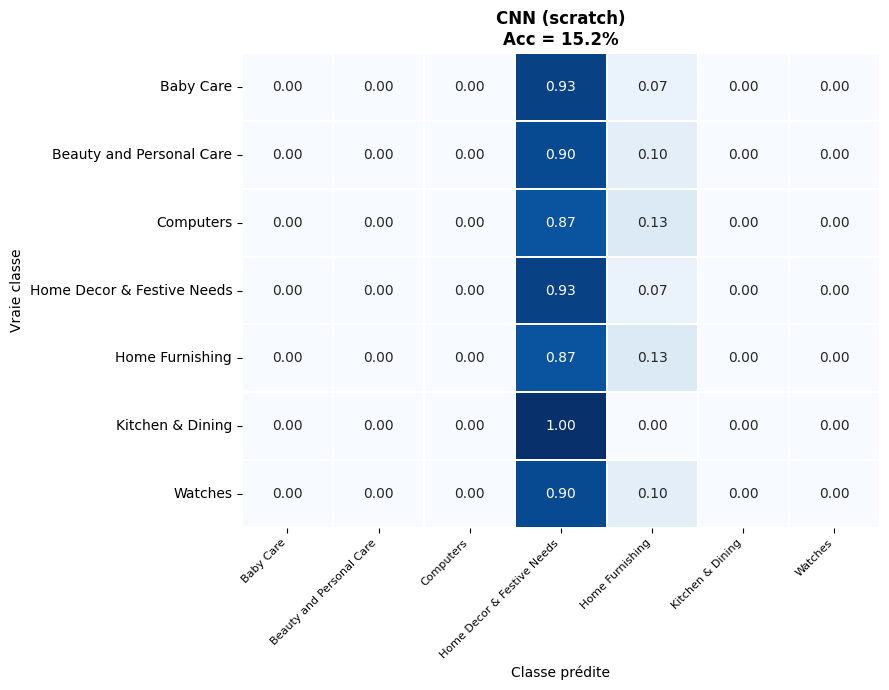

In [8]:
model_files = {
    "CNN (scratch)":       "cnn_scratch.keras",
    
}

n = len(model_files)
fig, axes = plt.subplots(1, n, figsize=(9*n, 7))
cmaps = ["Blues", "Reds", "Greens"]

if n == 1: axes = [axes]

for ax, cmap, (name, fname) in zip(axes, cmaps, model_files.items()):
    path = OUT_MODELS + fname
    if not os.path.exists(path):
        ax.text(0.5,0.5,f"{name}\nnon disponible",ha="center",va="center",
                transform=ax.transAxes,fontsize=12); continue
    m      = keras.models.load_model(path)
    y_pred = np.argmax(m.predict(X_test, verbose=0), axis=1)
    cm     = confusion_matrix(y_test, y_pred).astype(float)
    cm    /= cm.sum(axis=1)[:, np.newaxis]
    acc    = np.mean(y_pred == y_test)
    sns.heatmap(cm, annot=True, fmt=".2f", cmap=cmap,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.3, cbar=False)
    ax.set_title(f"{name}\nAcc = {acc*100:.1f}%", fontweight="bold")
    ax.set_xlabel("Classe prédite"); ax.set_ylabel("Vraie classe")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)

plt.tight_layout()
plt.savefig(OUT_PLOTS + "06_confusion_all.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Comparaison t-SNE des features des 3 modèles

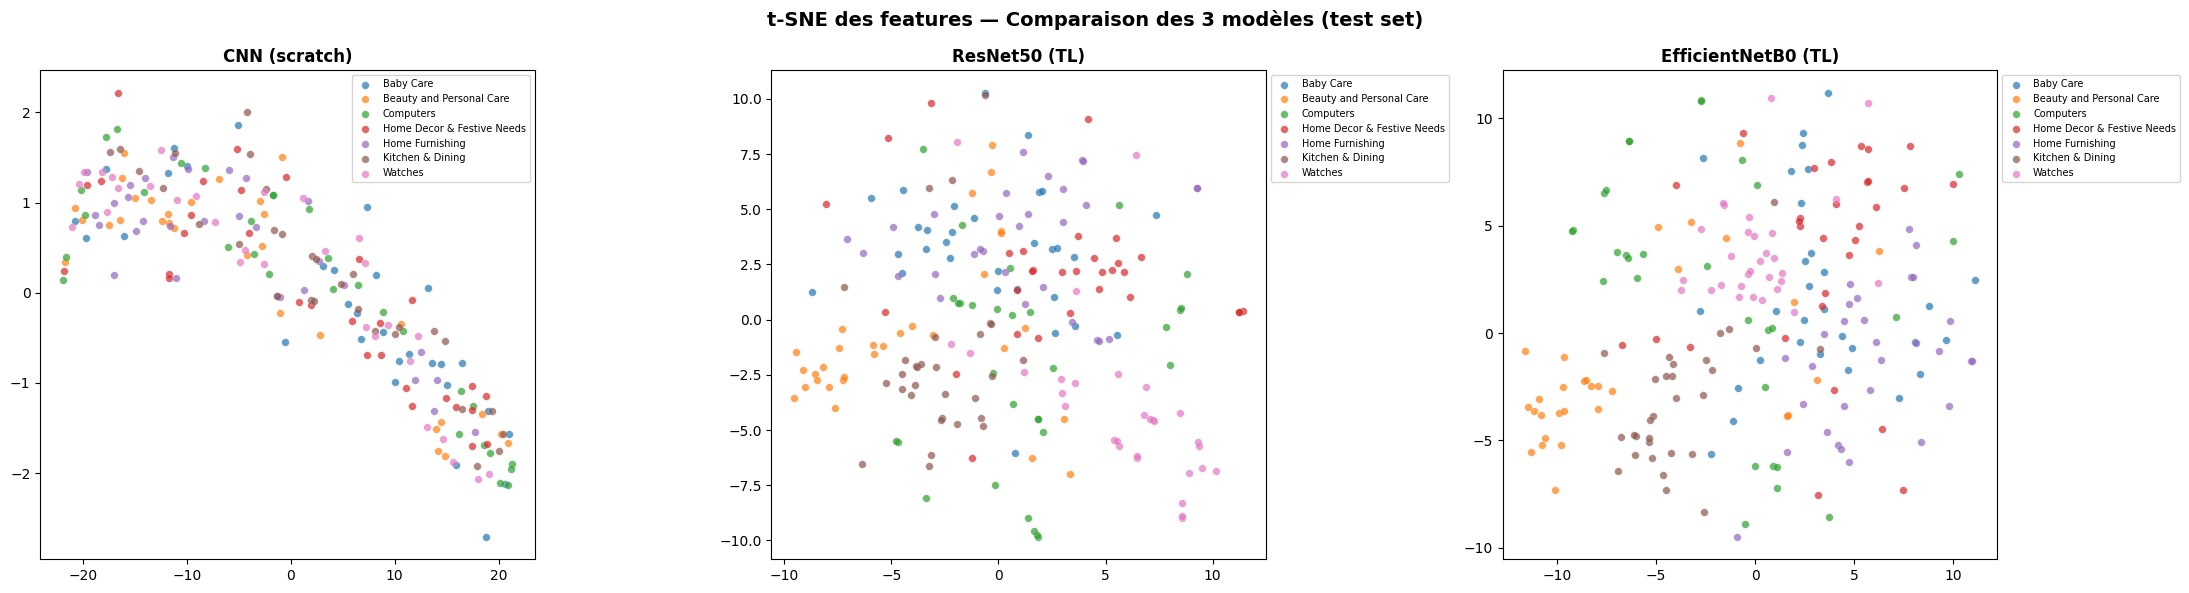

In [11]:
feature_files = {
    "CNN (scratch)":       "features_test_cnn.npy",
    "ResNet50 (TL)":       "features_test_resnet.npy",
    "EfficientNetB0 (TL)": "features_test_efficientnet.npy",
}
palette = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle("t-SNE des features — Comparaison des 3 modèles (test set)",
             fontsize=14, fontweight="bold")

for ax, (name, fname) in zip(axes, feature_files.items()):
    path = PROC_DIR + fname
    if not os.path.exists(path):
        ax.text(0.5,0.5,"Features\nnon disponibles",
                ha="center",va="center",transform=ax.transAxes); continue
    feat = np.load(path)
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=500)
    emb  = tsne.fit_transform(feat)
    for i in range(N_CLASSES):
        mask = (y_test == i)
        ax.scatter(emb[mask,0], emb[mask,1], label=CLASS_NAMES[i],
                   color=palette[i], alpha=0.7, s=30,
                   edgecolors="white", linewidths=0.2)
    ax.set_title(name, fontweight="bold")
    ax.legend(fontsize=7, bbox_to_anchor=(1,1))

plt.tight_layout()
plt.savefig(OUT_PLOTS + "06_tsne_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Export final pour Streamlit — `all_results.pkl`

In [12]:
# Ce fichier pkl est le SEUL fichier que Streamlit doit charger
# Il contient tout : métriques, historiques, noms de classes, chemins des modèles
streamlit_data = {
    "class_names":   list(CLASS_NAMES),
    "n_classes":     int(N_CLASSES),
    "img_size":      cfg["IMG_SIZE"],
    "models": []
}

for name, res in all_results.items():
    fname = {"CNN (scratch)":"cnn_scratch.keras",
             "ResNet50 (TL)":"resnet50.keras",
             "EfficientNetB0 (TL)":"efficientnet.keras"}[name]
    streamlit_data["models"].append({
        "name":       name,
        "model_file": fname,
        "accuracy":   res["accuracy"],
        "f1_score":   res["f1_score"],
        "history":    res["history"],
    })

# Sauvegarde pkl
with open(OUT_RESULTS + "all_results.pkl", "wb") as f:
    pickle.dump(streamlit_data, f)

# Sauvegarde JSON (lisible humainement)
json_safe = {k: v for k, v in streamlit_data.items() if k != "models"}
json_safe["models"] = [{k2:v2 for k2,v2 in m.items() if k2 != "history"}
                        for m in streamlit_data["models"]]
with open(OUT_RESULTS + "all_results.json", "w") as f:
    json.dump(json_safe, f, indent=2)

print("💾 outputs/results/all_results.pkl  ← utilisé par Streamlit")
print("💾 outputs/results/all_results.json ← version lisible")


💾 outputs/results/all_results.pkl  ← utilisé par Streamlit
💾 outputs/results/all_results.json ← version lisible


## 9. Bilan final & vérification des fichiers

In [13]:
print("="*65)
print("  ✅ NOTEBOOK 06 TERMINÉ — BILAN COMPLET")
print("="*65)

# Afficher le meilleur modèle
best = max(all_results.items(), key=lambda x: x[1]["accuracy"])
print(f"\n  🏆 MEILLEUR MODÈLE : {best[0]}")
print(f"     Accuracy : {best[1]['accuracy']*100:.2f}%")
print(f"     F1-Score : {best[1]['f1_score']*100:.2f}%")

print()
print("  TOUS LES FICHIERS GÉNÉRÉS :")

print("\n  📁 outputs/models/")
for f in sorted(os.listdir(OUT_MODELS)):
    size = os.path.getsize(OUT_MODELS+f)/1e6
    print(f"     {f:40} {size:.1f} MB")

print("\n  📁 outputs/plots/")
for f in sorted(os.listdir(OUT_PLOTS)):
    print(f"     {f}")

print("\n  📁 outputs/results/")
for f in sorted(os.listdir(OUT_RESULTS)):
    size = os.path.getsize(OUT_RESULTS+f)/1e6
    print(f"     {f:40} {size:.2f} MB")

print("\n  📁 data/processed/")
for f in sorted(os.listdir(PROC_DIR)):
    size = os.path.getsize(PROC_DIR+f)/1e6
    print(f"     {f:40} {size:.1f} MB")

print()
print("  → Lancer l'application Streamlit :")
print("    cd DL_Flipkart && streamlit run app/streamlit_app.py")
print("="*65)


  ✅ NOTEBOOK 06 TERMINÉ — BILAN COMPLET

  🏆 MEILLEUR MODÈLE : EfficientNetB0 (TL)
     Accuracy : 79.05%
     F1-Score : 78.77%

  TOUS LES FICHIERS GÉNÉRÉS :

  📁 outputs/models/
     cnn_scratch.keras                        4.0 MB
     efficientnet.keras                       37.4 MB
     resnet50.keras                           179.1 MB

  📁 outputs/plots/
     01_class_distribution.png
     01_image_sizes.png
     01_samples_per_category.png
     02_split_distribution.png
     02_train_samples.png
     03_augmentation.png
     03_cm_cnn_scratch.png
     03_curves_cnn_scratch.png
     03_tsne_cnn_scratch.png
     04_cm_resnet50.png
     04_curves_resnet50.png
     04_tsne_resnet50.png
     05_cm_efficientnet.png
     05_curves_efficientnet.png
     05_tsne_efficientnet.png
     06_comparison_final.png
     06_confusion_all.png
     06_training_curves_all.png
     06_tsne_comparison.png

  📁 outputs/results/
     all_results.json                         0.00 MB
     all_results.pkl 